# Skewness

Skewness refers to a distortion or asymmetry that deviates from the symmetrical bell curve, or normal distribution, in a set of data. The skewness value can be positive, negative, or undefined.

- Normally distributed data has a skewness of zero.
- **Positively skewed** data indicates a right-skewed distribution: more of extremely large values and fewer small ones.
- **Negatively skewed** data: lots of small values and a few extremely large ones.

#### Skewness formula

$$
\mbox{skewness}(X) = \frac{1}{N \hat{\sigma}^3} \sum_{i=1}^N (X_i - \bar{X})^3
$$

Where $N$ is the number of observations, $\bar{X}$ is the sample mean, and $\hat{\sigma}$ is the standard deviation (the "divide by $N-1$" version, that is)

In [134]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np
from scipy import stats

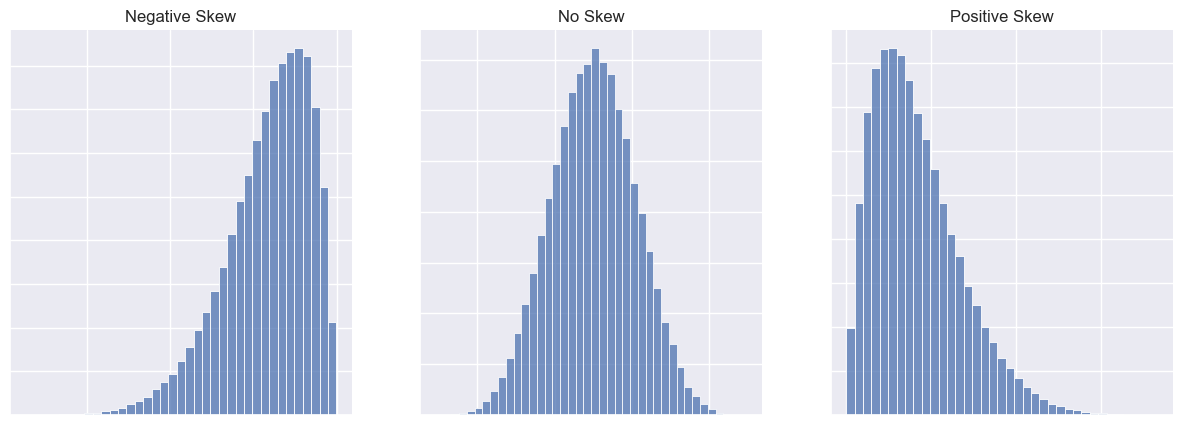

In [120]:
skewness = pd.read_csv('data/skewdata.csv')
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

ax1 = sns.histplot(data = skewness.loc[skewness['Skew'] == 'NegSkew'], x = 'Values', binwidth = 0.02, ax=axes[0])
ax2 = sns.histplot(data = skewness.loc[skewness['Skew'] == 'NoSkew'], x = 'Values', binwidth = 0.02, ax=axes[1])
ax3 = sns.histplot(data = skewness.loc[skewness['Skew'] == 'PosSkew'], x = 'Values', binwidth = 0.02, ax=axes[2])

axes[0].set_title("Negative Skew")
axes[1].set_title("No Skew")
axes[2].set_title("Positive Skew")

for ax in axes:
    ax.set(xticklabels=[])
    ax.set(yticklabels=[])
    ax.set(xlabel=None)
    ax.set(ylabel=None)
    ax.tick_params(bottom=False)
    ax.tick_params(left=False)

sns.despine()

### Examples (skewness)

#### Example 1 (skewness)

In [146]:
incomes = np.random.normal(27000, 15000, 10000)
incomes = np.append(incomes, [1000000000])

In [147]:
np.median(incomes), np.mean(incomes)

(np.float64(26943.73052325097), np.float64(127041.26362625472))

In [148]:
df = pd.DataFrame(incomes)
df.skew()

0    100.004673
dtype: float64

#### Calculate skewness using statsmodels

statsmodels will return:
- The standard skewness estimator.
- The skewness estimator based on quartiles.
- The skewness estimator based on mean-median difference, standardized by absolute deviation.
- The skewness estimator based on the mean-median difference, standardized by standard deviation.


In [149]:
sm.stats.stattools.robust_skewness(incomes)

(np.float64(99.98967334255352),
 np.float64(0.02438907800816896),
 np.float64(0.8952980380079538),
 np.float64(0.01001101422407293))

#### Example 2 (skewness)

In [150]:
sp_data = pd.read_csv("data/SP_500_1987.csv", parse_dates=["Date"])
sp_data['Volume'] = sp_data['Volume'].str.replace(',', '').astype(int)
sp_data['Returns'] = sp_data['Close'].pct_change()
sp_data.dropna(inplace=True)
sp_data['Returns'].skew()

np.float64(-4.063006900553241)

In [151]:
sm.stats.stattools.robust_skewness(sp_data['Returns'])

(np.float64(-4.038782236530137),
 np.float64(0.033689707286255054),
 np.float64(-0.11690104948849872),
 np.float64(-0.06460582304845877))